<h2><span style="color:darkviolet">Argon Gas Phase Simulations</span></h2>

This notebook aims to reproduce the results obtained from Molecular Dynamics and Markov Chain Monte Carlo simulations for Argon, focusing on the **gas phase**. The objective is to achieve and study a thermodynamically equilibrated configuration under the following reduced conditions, derived from the input parameters:

- **Reduced Density**: $\rho^\star = 0.8$
- **Reduced Temperature**: $T^\star = 1.1$
- **Cut-off Radius**: $r_c = 2.5 \sigma$

Since the initial configuration of the system is a FCC lattice, which is characteristic of a solid phase, the system must undergo one or more **phase transitions** to properly reach the configuration representative of the target gas phase. Consequently, the **equilibration** simulation must be run for a **longer** duration compared to a liquid phase simulation, which starts closer to the target density and does not typically require multiple phase transitions.

The parameters used for the equilibration run were:

<div align="center">

| Parameters | NVE equilibration | NVT equilibration |
| :--- | :--- | :--- |
| SIMULATION_TYPE | 0 | 1 |
| DISTRIBUTION_TYPE | 0 | - |
| RESTART | 0 | 0 |
| TEMP | 0.95 | 1.2 |
| NPART | 108 | 108 |
| RHO | 0.05 | 0.05 |
| R_CUT | 5.0 | 5.0 |
| DELTA | 0.001 | 4.8 |
| NBLOCKS | 150000 | 30000 |
| NSTEPS | 1 | 1 |
| TAILS | 1 | 1 |

</div>

To determine the system's **correlation time** and the **optimal block length** for statistical analysis, a $500000$ steps simulation was executed, starting from the equilibrated system configuration.

The input parameters for this run were:

<div align="center">

| Parameters | NVE autocorrelation | NVT autocorrelation |
| :--- | :--- | :--- |
| SIMULATION_TYPE | 0 | 1 |
| DISTRIBUTION_TYPE | 0 | - |
| RESTART | 1 | 1 |
| TEMP | 1.20001 | 1.2 |
| NPART | 108 | 108 |
| RHO | 0.8 | 0.8 |
| R_CUT | 2.5 | 2.5 |
| DELTA | 0.001 | 0.1005 |
| NBLOCKS | 500000 | 500000 |
| NSTEPS | 1 | 1 |
| TAILS | 1 | 1 |

</div>

Once the system has been properly equilibrated and the block lenght was calculated, the objective is:

- To graphically represent the progressive block averages for both the potential energy per particle and the pressure, including their respective statistical uncertainties.

- To produce the Radial Distribution Function ($g(r)$) plots for both ensembles (NVE and NVT).

The input parameters used for the final production simulations were:

<div align="center">

| Parameters | NVE simulation | NVT simulation |
| :--- | :--- | :--- |
| SIMULATION_TYPE | 0 | 1 |
| DISTRIBUTION_TYPE | 0 | - |
| RESTART | 1 | 1 |
| TEMP | 1.20001 | 1.2 |
| NPART | 108 | 108 |
| RHO | 0.8 | 0.8 |
| R_CUT | 2.5 | 2.5 |
| DELTA | 0.001 | 0.1005 |
| NBLOCKS | 100 | 100 |
| NSTEPS | 3000 | 3000 |
| TAILS | 1 | 1 |

</div>

In [65]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# =========================================================
# GLOBAL CONFIGURATION (rcParams)
# =========================================================

# 1. FONT AND TEXT SETTINGS
# ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Lato', 'DejaVu Sans'],  # Priority list of clean fonts
    'font.size': 11,                                                   # Base font size for all elements

    # Specific settings for titles and axes
    'axes.titlesize': 15,                                              # Larger plot title size
    'axes.titleweight': 'bold',                                        # Bold title for emphasis
    'axes.labelsize': 13,                                              # Axis labels size (larger than base)
    'legend.fontsize': 11,                                             # Legend text size
})


# 2. AXES, TICKS, AND GRID SETTINGS
# ---
plt.rcParams.update({
    # GRID: Light and non-intrusive
    'axes.grid': True,              # Enable grid by default
    'grid.linestyle': '--',         # Dashed grid lines
    'grid.color': 'lightgray',      # Light color for grid
    'grid.alpha': 0.7,              # Transparency for grid

    # AXES SPINES (The box outline)
    'axes.spines.right': True,      # Draw right spine
    'axes.spines.top': True,        # Draw top spine
    'axes.edgecolor': 'black',      # Black color for the box outline
    'axes.linewidth': 1.2,          # Thickness of the box outline

    # MAJOR TICKS (The main markings with numbers)
    'xtick.direction': 'in',        # Major ticks pointing inwards
    'ytick.direction': 'in',
    'xtick.major.size': 6,          # Major tick length
    'ytick.major.size': 6,
    'xtick.top': True,              # Draw major ticks on the top side
    'ytick.right': True,            # Draw major ticks on the right side
    'xtick.labeltop': True,         # Show numbers on the upper X axis
    'ytick.labelright': True,       # Show numbers on the right Y axis
    
    # MINOR TICKS (Small markings between major ticks)
    'xtick.minor.visible': True,    # Enable minor ticks
    'ytick.minor.visible': True,
    'xtick.minor.top': True,        # Draw minor ticks on the top side
    'ytick.minor.right': True,
    'xtick.minor.size': 4,          # Minor tick length
    'xtick.minor.width': 0.8,       # Minor tick thickness
    'ytick.minor.width': 0.8,
})


# 3. LINES AND MARKERS SETTINGS
# ---
plt.rcParams.update({
    'lines.linewidth': 2.0,         # Default thickness for primary plot lines
    'lines.markersize': 4,          # Default size for data markers
    'lines.markeredgewidth': 1.0,   # Controls marker border thickness AND errorbar caps
})


# 4. ERRORBAR SETTINGS
# ---
plt.rcParams.update({
    'errorbar.capsize': 0.0,        # Length of the horizontal "caps" at the ends
})


# 5. LEGEND AND SAVING SETTINGS
# ---
plt.rcParams.update({
    # High-quality export settings (Best for a thesis)
    'figure.dpi': 300,              # Default display resolution (high quality)
    'savefig.format': 'png',        # Default save format to PNG (Vector format)
    'savefig.bbox': 'tight',        # Automatically trim excess white space
    'savefig.pad_inches': 0.05,     # Small padding to prevent clipping

    # Legend Appearance
    'legend.frameon': True,         # Draw a box around the legend
    'legend.edgecolor': 'lightgray',# Light border for the legend box
    'legend.fancybox': True,        # Slightly rounded legend border
})

In [66]:
equil_step_NVT = 30000
equil_step_NVE = 150000
acf_step = 10000

In [67]:
temp = np.loadtxt("MD_NVE/gas/equilibration/OUTPUT/temperature.dat", usecols=(1), unpack=True)
accept = np.loadtxt("MC_NVT/gas/equilibration/OUTPUT/acceptance.dat", usecols=(1), unpack=True)
poten_en = np.loadtxt("MC_NVT/gas/equilibration/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)
x_NVE = np.arange(0, equil_step_NVE)
x_NVT = np.arange(0, equil_step_NVT)

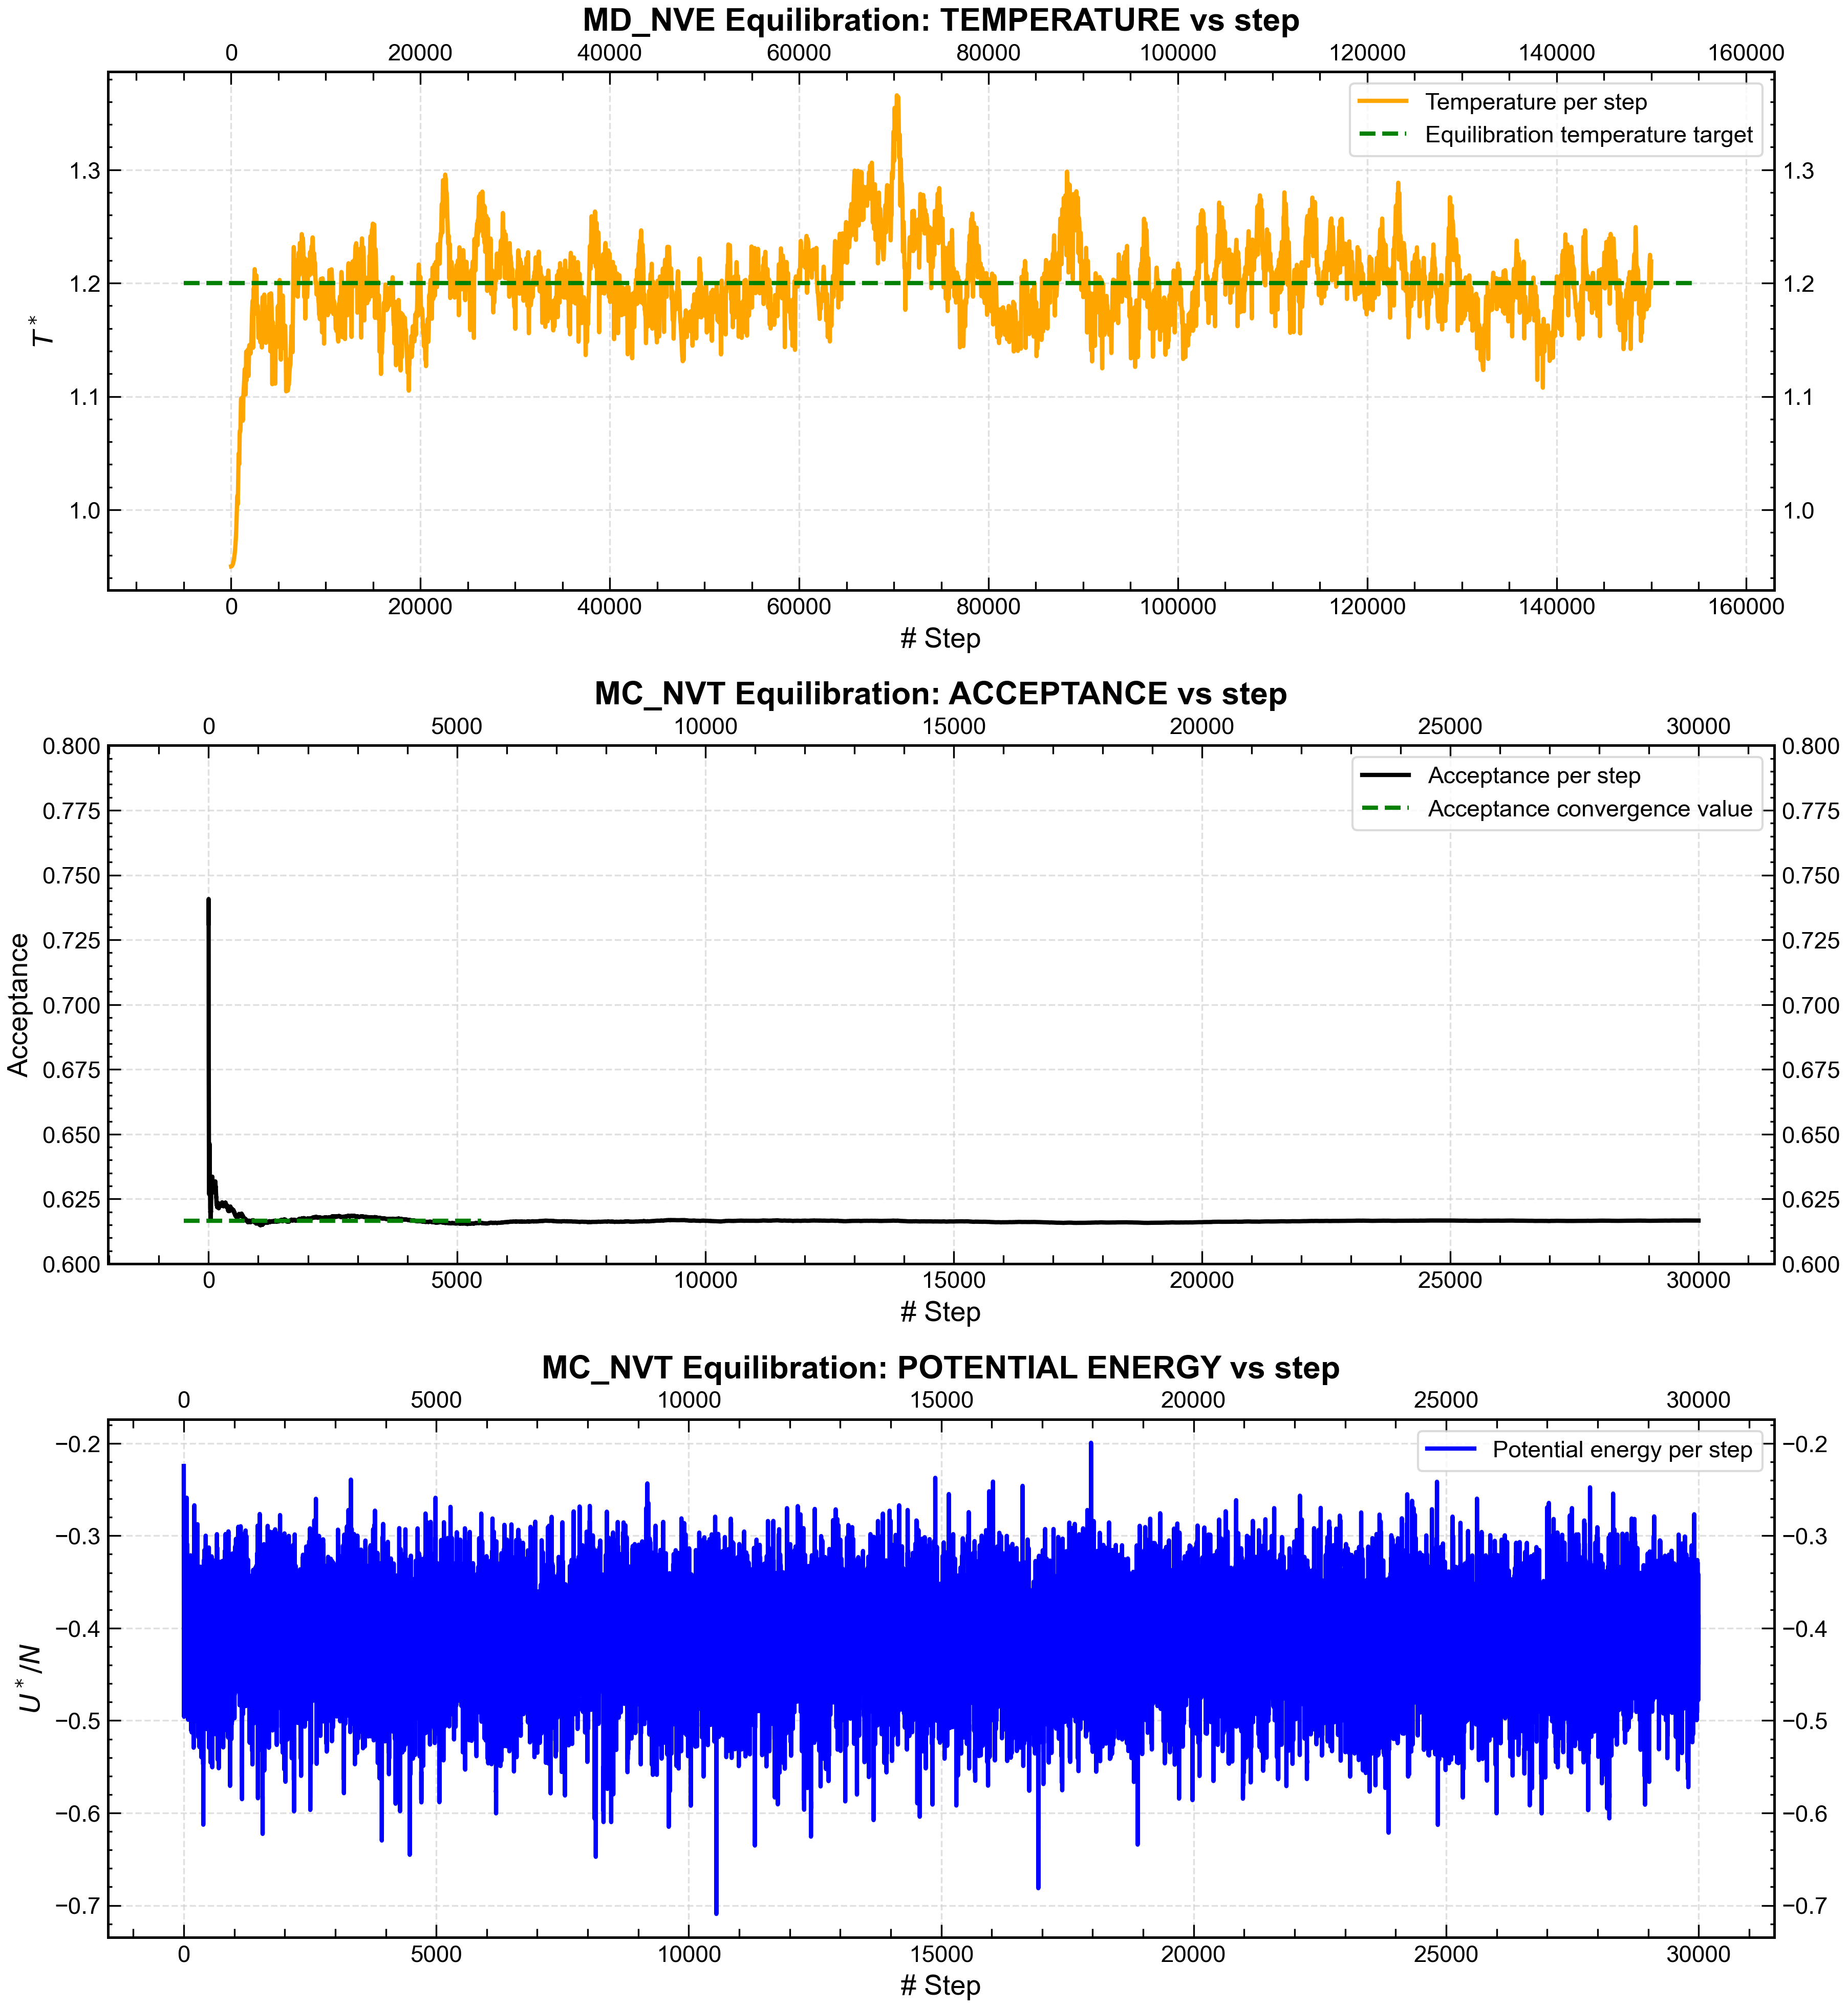

In [68]:
fig, axs = plt.subplots(3,1, figsize=(14,15))

axs[0].set_title("MD_NVE Equilibration: TEMPERATURE vs step")
axs[0].set_xlabel("# Step")
axs[0].set_ylabel(r"$T^*$")
axs[0].plot(x_NVE, temp, color="orange", label="Temperature per step")
axs[0].hlines(1.20, -5000, x_NVE[-1]+5000, color="green", linestyle="--", label="Equilibration temperature target")
axs[0].legend()

axs[1].set_title("MC_NVT Equilibration: ACCEPTANCE vs step")
axs[1].set_xlabel("# Step")
axs[1].set_ylabel("Acceptance")
axs[1].plot(x_NVT, accept, color="black", label="Acceptance per step")
axs[1].hlines(0.6166, -500, x[-1]+500, color="green", linestyle="--", label="Acceptance convergence value")
axs[1].set_ylim(0.6, 0.8)
axs[1].legend()

axs[2].set_title("MC_NVT Equilibration: POTENTIAL ENERGY vs step")
axs[2].set_xlabel("# Step")
axs[2].set_ylabel(r"$U^*/N$")
axs[2].plot(x_NVT, poten_en, color="blue", label="Potential energy per step")
axs[2].legend()

fig.subplots_adjust(
        wspace=0.3,  # Spazio orizzontale
        hspace=0.3, # Spazio verticale
        top=0.92     # move below plots (gives space to suptitle)
)
fig.savefig("plot/gas/equilibration/equilibration.png")

plt.show()

<h4>Conclusions</h4>

It can be observed that the gas phase requires a significantly longer time to equilibrate compared to the condensed phases (liquid or solid).

The MD simulation in the NVE ensemble, which conserves energy, requires a prolonged run for the temperature to stabilize. Specifically, the kinetic temperature requires approximately $80,000$ timesteps to reach a stable average value corresponding to the target equilibrium temperature of $T^{\star} = 1.2$. In contrast, the MCMC simulation in the NVT ensemble (where the temperature is actively controlled) requires far fewer steps for thermalization. This rapid convergence is characteristic of the Metropolis algorithm, which efficiently samples the configurations of the system according to the Boltzmann distribution. The system reached thermal equilibrium after only $10,000$ MC steps (equivalent to $10,000 \times N = 1,080,000$ attempted Metropolis moves for $N=108$ particles). The acceptance ratio of the Metropolis moves was observed to converge quickly to a value of approximately $0.61$. This value is close to the theoretical optimum often cited in the literature (e.g., $0.5$ in some cases, or slightly higher/lower depending on the system), and it represents the chosen minimum acceptance ratio found by tuning the displacement step $\Delta = 4.8$ in the Metropolis algorithm.

In [69]:
def barlett_window(tau, tau_max = acf_step/10):
    if(tau > tau_max):
        return 0.0
    return 1 - (tau/tau_max)

def unbiased_acf(quantity, var):
    
    t_max = len(quantity)
    acorr = np.zeros(t_max)

    for t in range(t_max):

        delta_t = t_max - t
        norm_num = 1.0 / delta_t
        x = 0.0
        y = 0.0
        xy = 0.0

        for t_prime in range(delta_t):

            x += quantity[t_prime]
            y += quantity[t_prime + t]
            xy += quantity[t_prime] * quantity[t_prime + t]

        
        num = norm_num * xy - (norm_num * x) * (norm_num * y)
        acorr[t] = num / var

    return acorr

def biased_acf(quantity, var):
    
    t_max = len(quantity)
    acorr = np.zeros(t_max)

    for t in range(t_max):

        delta_t = t_max - t
        norm = 1.0 / t_max
        xy = 0.0

        for t_prime in range(delta_t):
            xy += quantity[t_prime] * quantity[t_prime + t]
        
        num = norm * xy
        acorr[t] = (num / var) 

    return acorr

def integrated_ac_time(ac): 
    try:
        zero_crossing = np.where(ac < 0)[0][0]
    except IndexError:
        zero_crossing = len(ac)
    return 1 + 2 * np.sum(ac[1:zero_crossing])

In [70]:
potential_NVE = np.loadtxt("MD_NVE/gas/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)[:acf_step]
potential_NVT = np.loadtxt("MC_NVT/gas/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)[:acf_step]

var_NVE = np.var(potential_NVE)
var_NVT = np.var(potential_NVT)

unbiased_acf_NVE = unbiased_acf(potential_NVE, var_NVE)
unbiased_acf_NVT = unbiased_acf(potential_NVT, var_NVT)

In [71]:
unbiased_acf_NVE_barlett = unbiased_acf_NVE * [barlett_window(t) for t in range(acf_step)]
unbiased_acf_NVT_barlett = unbiased_acf_NVT * [barlett_window(t) for t in range(acf_step)]

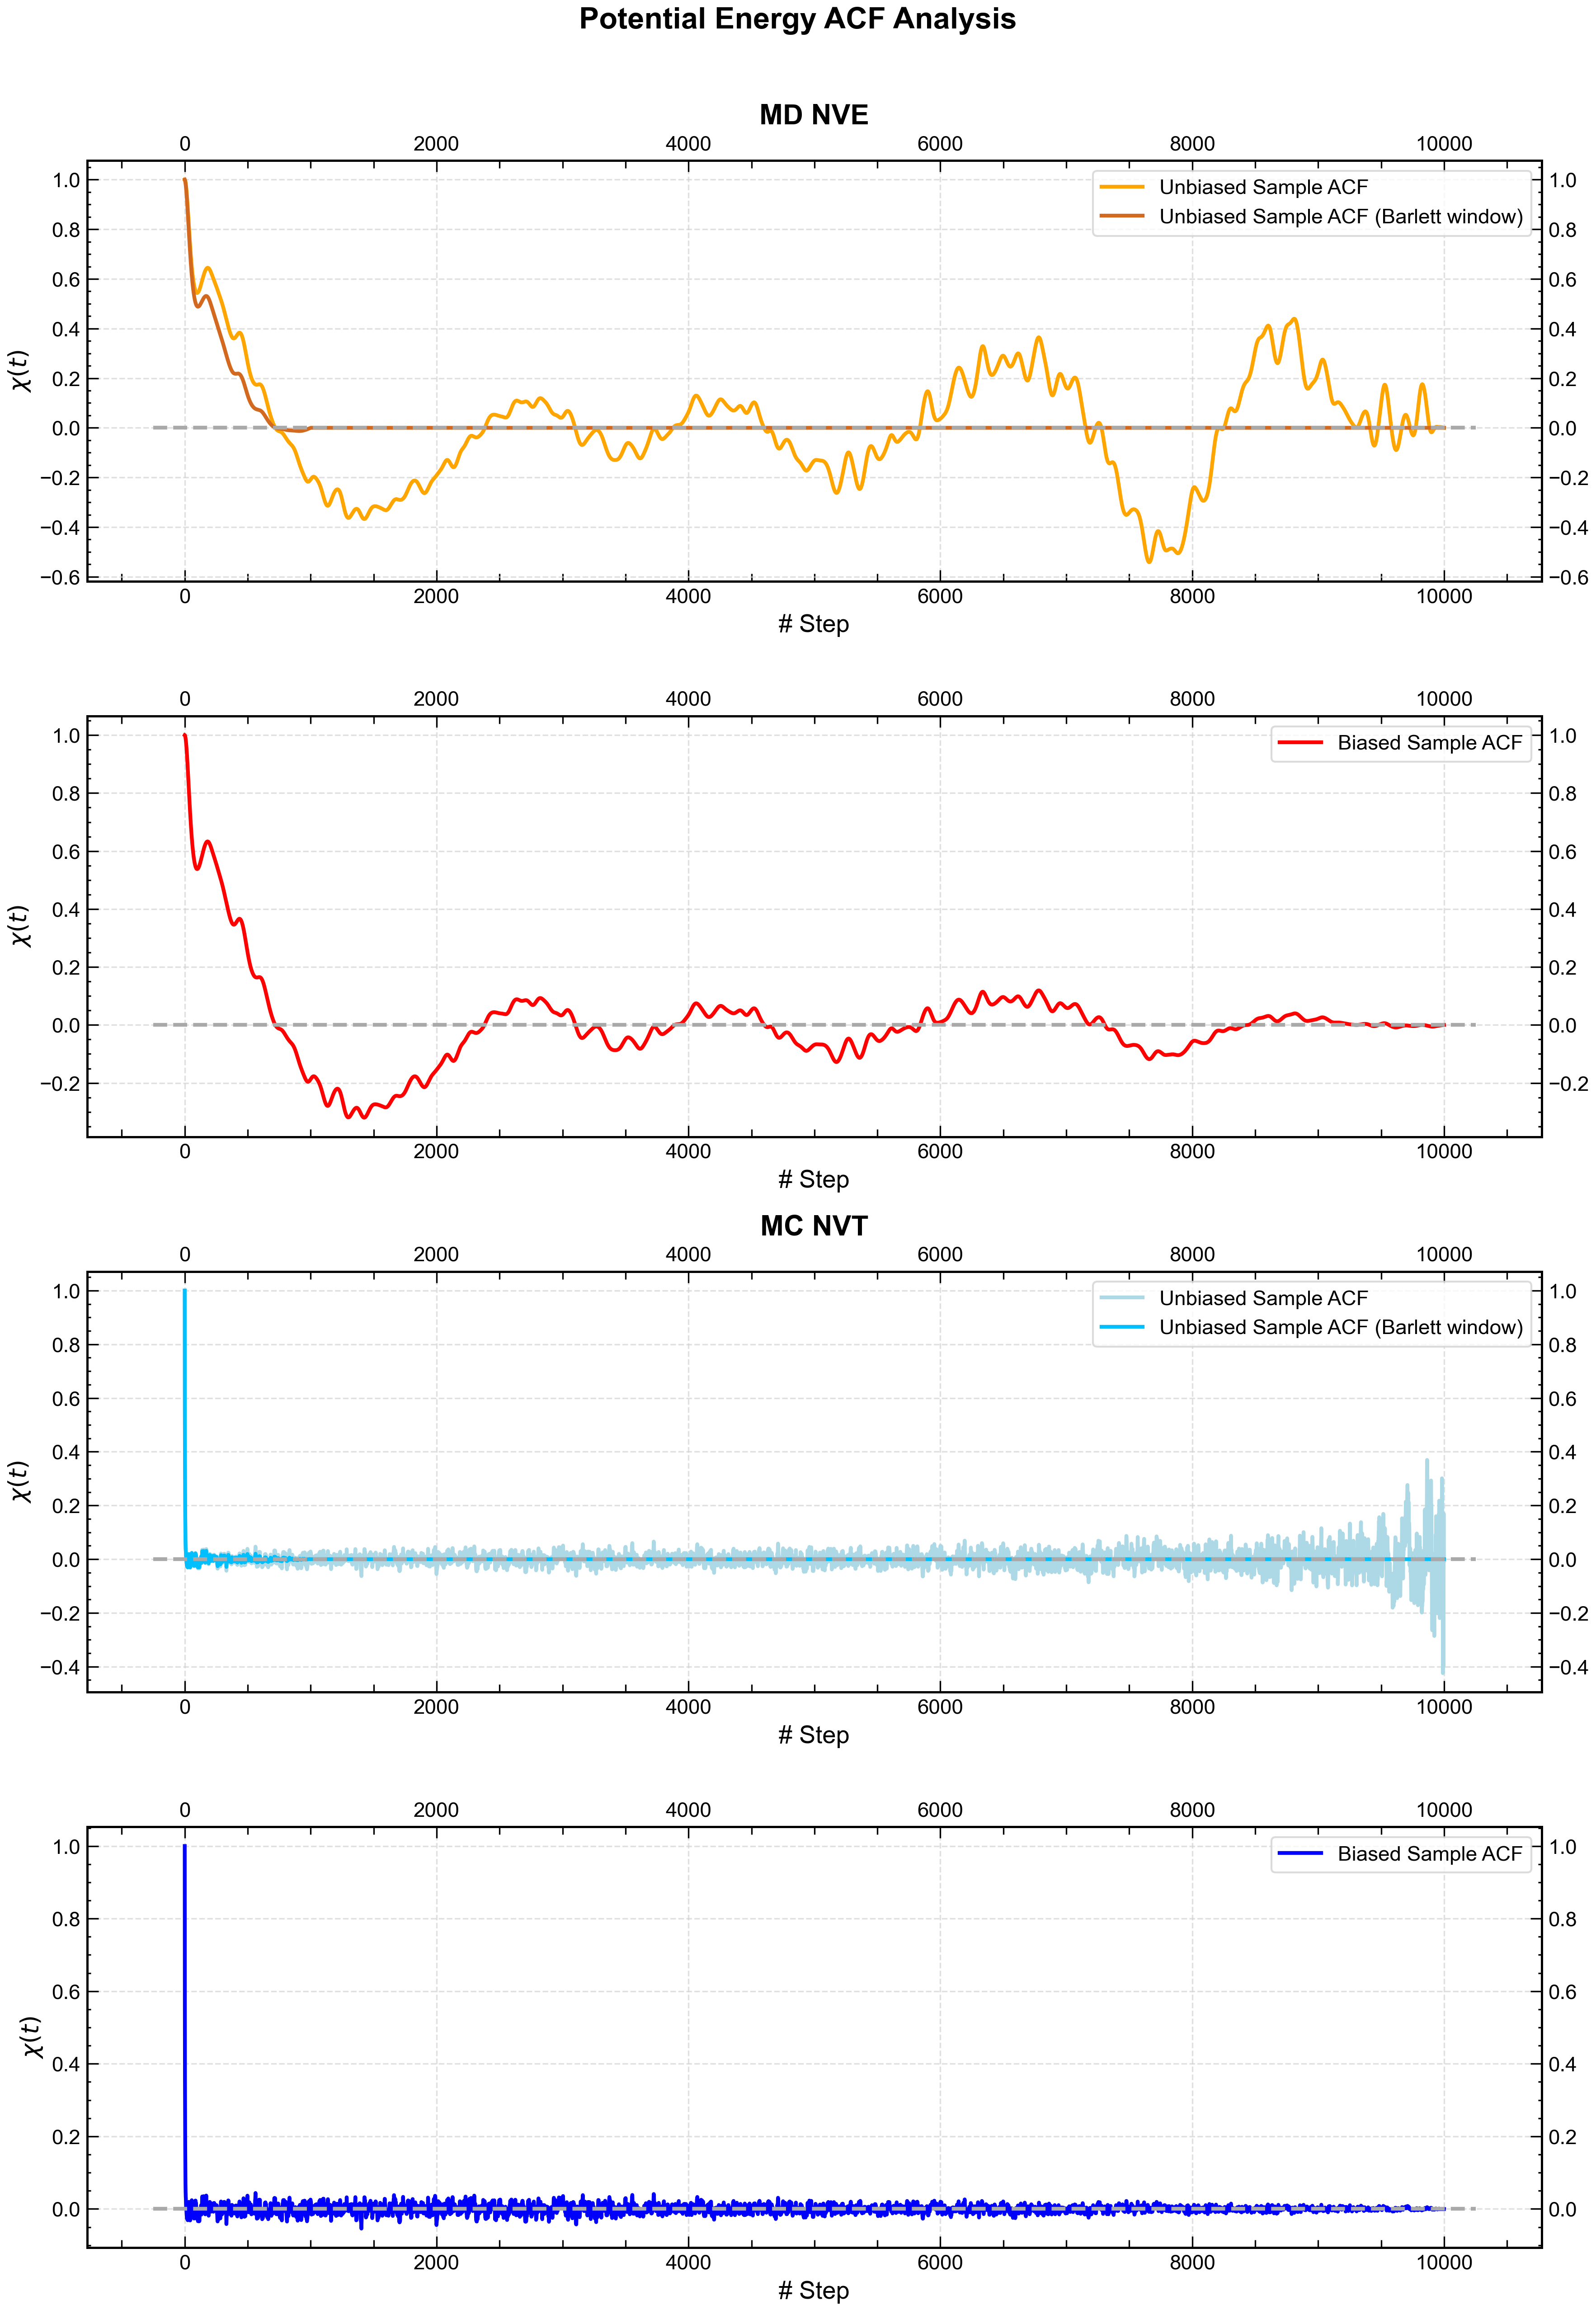

NVE Correlation time from unbiased sample ACF : τ ≈ 592.55 steps
NVE Correlation time from biased sample ACF : τ ≈ 577.68 steps
NVT Correlation time from unbiased sample ACF : τ ≈ 4.33 steps
NVT Correlation time from biased sample ACF : τ ≈ 4.33 steps


In [72]:
# Assumo che acf_step, unbiased_acf_NVE, ecc. siano stati definiti
x = np.arange(0, acf_step) 

fig, axs = plt.subplots(4, 1, figsize=(12, 18)) 

fig.suptitle("Potential Energy ACF Analysis", fontweight="bold", fontsize=16)

axs[0].set_title("MD NVE")
axs[0].plot(x, unbiased_acf_NVE, color="orange", label="Unbiased Sample ACF")
axs[0].plot(x, unbiased_acf_NVE_barlett, color="chocolate", label="Unbiased Sample ACF (Barlett window)")
axs[0].set_xlabel("# Step")
axs[0].set_ylabel(r"$\chi(t)$")
# axs[0].set_xlim(-500,10500)
# axs[0].set_ylim(-0.5,1.2)
axs[0].plot([-250, 10250], [0.0,0.0], color="darkgrey", linestyle="--")
axs[0].legend()

axs[1].plot(x, biased_acf_NVE, color="red", label="Biased Sample ACF")
axs[1].set_xlabel("# Step")
axs[1].set_ylabel(r"$\chi(t)$")
# axs[1].set_xlim(-500,10500)
# axs[1].set_ylim(-0.5,1.2)
axs[1].plot([-250, 10250], [0.0,0.0], color="darkgrey", linestyle="--")
axs[1].legend()

axs[2].set_title("MC NVT")
axs[2].plot(x, unbiased_acf_NVT, color="lightblue", label="Unbiased Sample ACF")
axs[2].plot(x, unbiased_acf_NVT_barlett, color="deepskyblue", label="Unbiased Sample ACF (Barlett window)")
axs[2].set_xlabel("# Step")
axs[2].set_ylabel(r"$\chi(t)$")
# axs[2].set_xlim(-500,10500)
# axs[2].set_ylim(-0.5,1.2)
axs[2].plot([-250, 10250], [0.0,0.0], color="darkgrey", linestyle="--")
axs[2].legend()

axs[3].plot(x, biased_acf_NVT, color="blue", label="Biased Sample ACF")
axs[3].set_xlabel("# Step")
axs[3].set_ylabel(r"$\chi(t)$")
# axs[3].set_xlim(-500,10500)
# axs[3].set_ylim(-0.5,1.2)
axs[3].plot([-250, 10250], [0.0,0.0], color="darkgrey", linestyle="--")
axs[3].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])

fig.savefig("plot/gas/autocorrelation/autocorrelation_pot_energy.png")
plt.show()

NVE_ct_unbias = integrated_ac_time(unbiased_acf_NVE)
NVE_ct_bias = integrated_ac_time(biased_acf_NVE)
NVT_ct_unbias = integrated_ac_time(unbiased_acf_NVT)
NVT_ct_bias = integrated_ac_time(biased_acf_NVT)

print(f"NVE Correlation time from unbiased sample ACF : τ ≈ {NVE_ct_unbias:.2f} steps")
print(f"NVE Correlation time from biased sample ACF : τ ≈ {NVE_ct_bias:.2f} steps")
print(f"NVT Correlation time from unbiased sample ACF : τ ≈ {NVT_ct_unbias:.2f} steps")
print(f"NVT Correlation time from biased sample ACF : τ ≈ {NVT_ct_bias:.2f} steps")

In [73]:
def error(A_sum: float, A_sq_sum: float, i: int) -> float:
    
    # N_samp is the number of samples (blocks) calculated so far
    N_samp = i + 1 
    
    # If we have less than 2 samples, we cannot calculate the variance (ddof=1)
    if N_samp < 2:
        return 0.0
    
    # Calculate the cumulative mean of the squared block means (S2 / N_samp)
    A_sq_mean = A_sq_sum / N_samp
    # Calculate the cumulative mean of the block means (S1 / N_samp)
    A_mean = A_sum / N_samp

    # Calculate the variance numerator: E[A^2] - (E[A])^2
    num = A_sq_mean - A_mean**2

    # Calculate the Standard Deviation of the block means
    err = np.sqrt(num/(N_samp - 1))
    
    return err


def data_blocking(obs: np.ndarray, L: int) -> float:    # Calculates the final progressive error for a specific block length L
    
    M = len(obs)    # Total dataset size
    if L <= 0:
        return np.nan

    # Calculate N (number of blocks) using integer division (//)
    N = M // L
    
    if N < 2:
        # Cannot calculate variance with less than 2 blocks.
        return np.nan 
    
    # Determine the effective length of the data to be used (exact multiple of L)
    L_eff = N * L
    
    # Vectorized Calculation of Block Means (A_i)
    # 1. Truncation: obs[:L_eff] selects the data divisible by L
    # 2. Reshape: .reshape(N, L) creates a matrix where each row is a block 
    # 3. Mean: .mean(axis=1) calculates the mean for each row (single block mean A_i)
    block_means = obs[:L_eff].reshape(N, L).mean(axis=1)
    
    A_sum = 0.0      # Accumulator variable: Cumulative sum of block means (S1)
    A_sq_sum = 0.0   # Accumulator variable: Cumulative sum of squared block means (S2)
    
    last_error = 0.0 # Variable to store the error calculated on the last block

    # Loop over the N block means to calculate the progressive error
    for i in range(N):
        A_k = block_means[i]  # Current block mean (A_i)
        
        # Update the cumulative sum of means
        A_sum += A_k
        # Update the cumulative sum of squared means
        A_sq_sum += A_k * A_k
        
        # The final error (err[-1]) is calculated and saved only on the last iteration (i = N-1)
        if(i==N-1):
            last_error = error(A_sum, A_sq_sum, i)

    return last_error

In [74]:
# Dataset loading
potential_NVE = np.loadtxt("MD_NVE/gas/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)
potential_NVT = np.loadtxt("MC_NVT/gas/autocorrelation_run/OUTPUT/potential_energy.dat", usecols=(1), unpack=True)

# Minimum block size
L_min = 10
# Maximum block size
L_max = 5000
# Array of tested block sizes
L_values = np.arange(L_min, L_max + 1)
# Number of block sizes attempted
num_L = len(L_values)
# Arrays for calculated errors corresponding to successive block sizes
err_NVE = np.zeros(num_L)
err_NVT = np.zeros(num_L)

# Loop over the tested block sizes and fill the respective error arrays
for i in range(num_L):
    L = L_values[i]
    err_NVE[i] = data_blocking(potential_NVE, L)
    err_NVT[i] = data_blocking(potential_NVT, L)

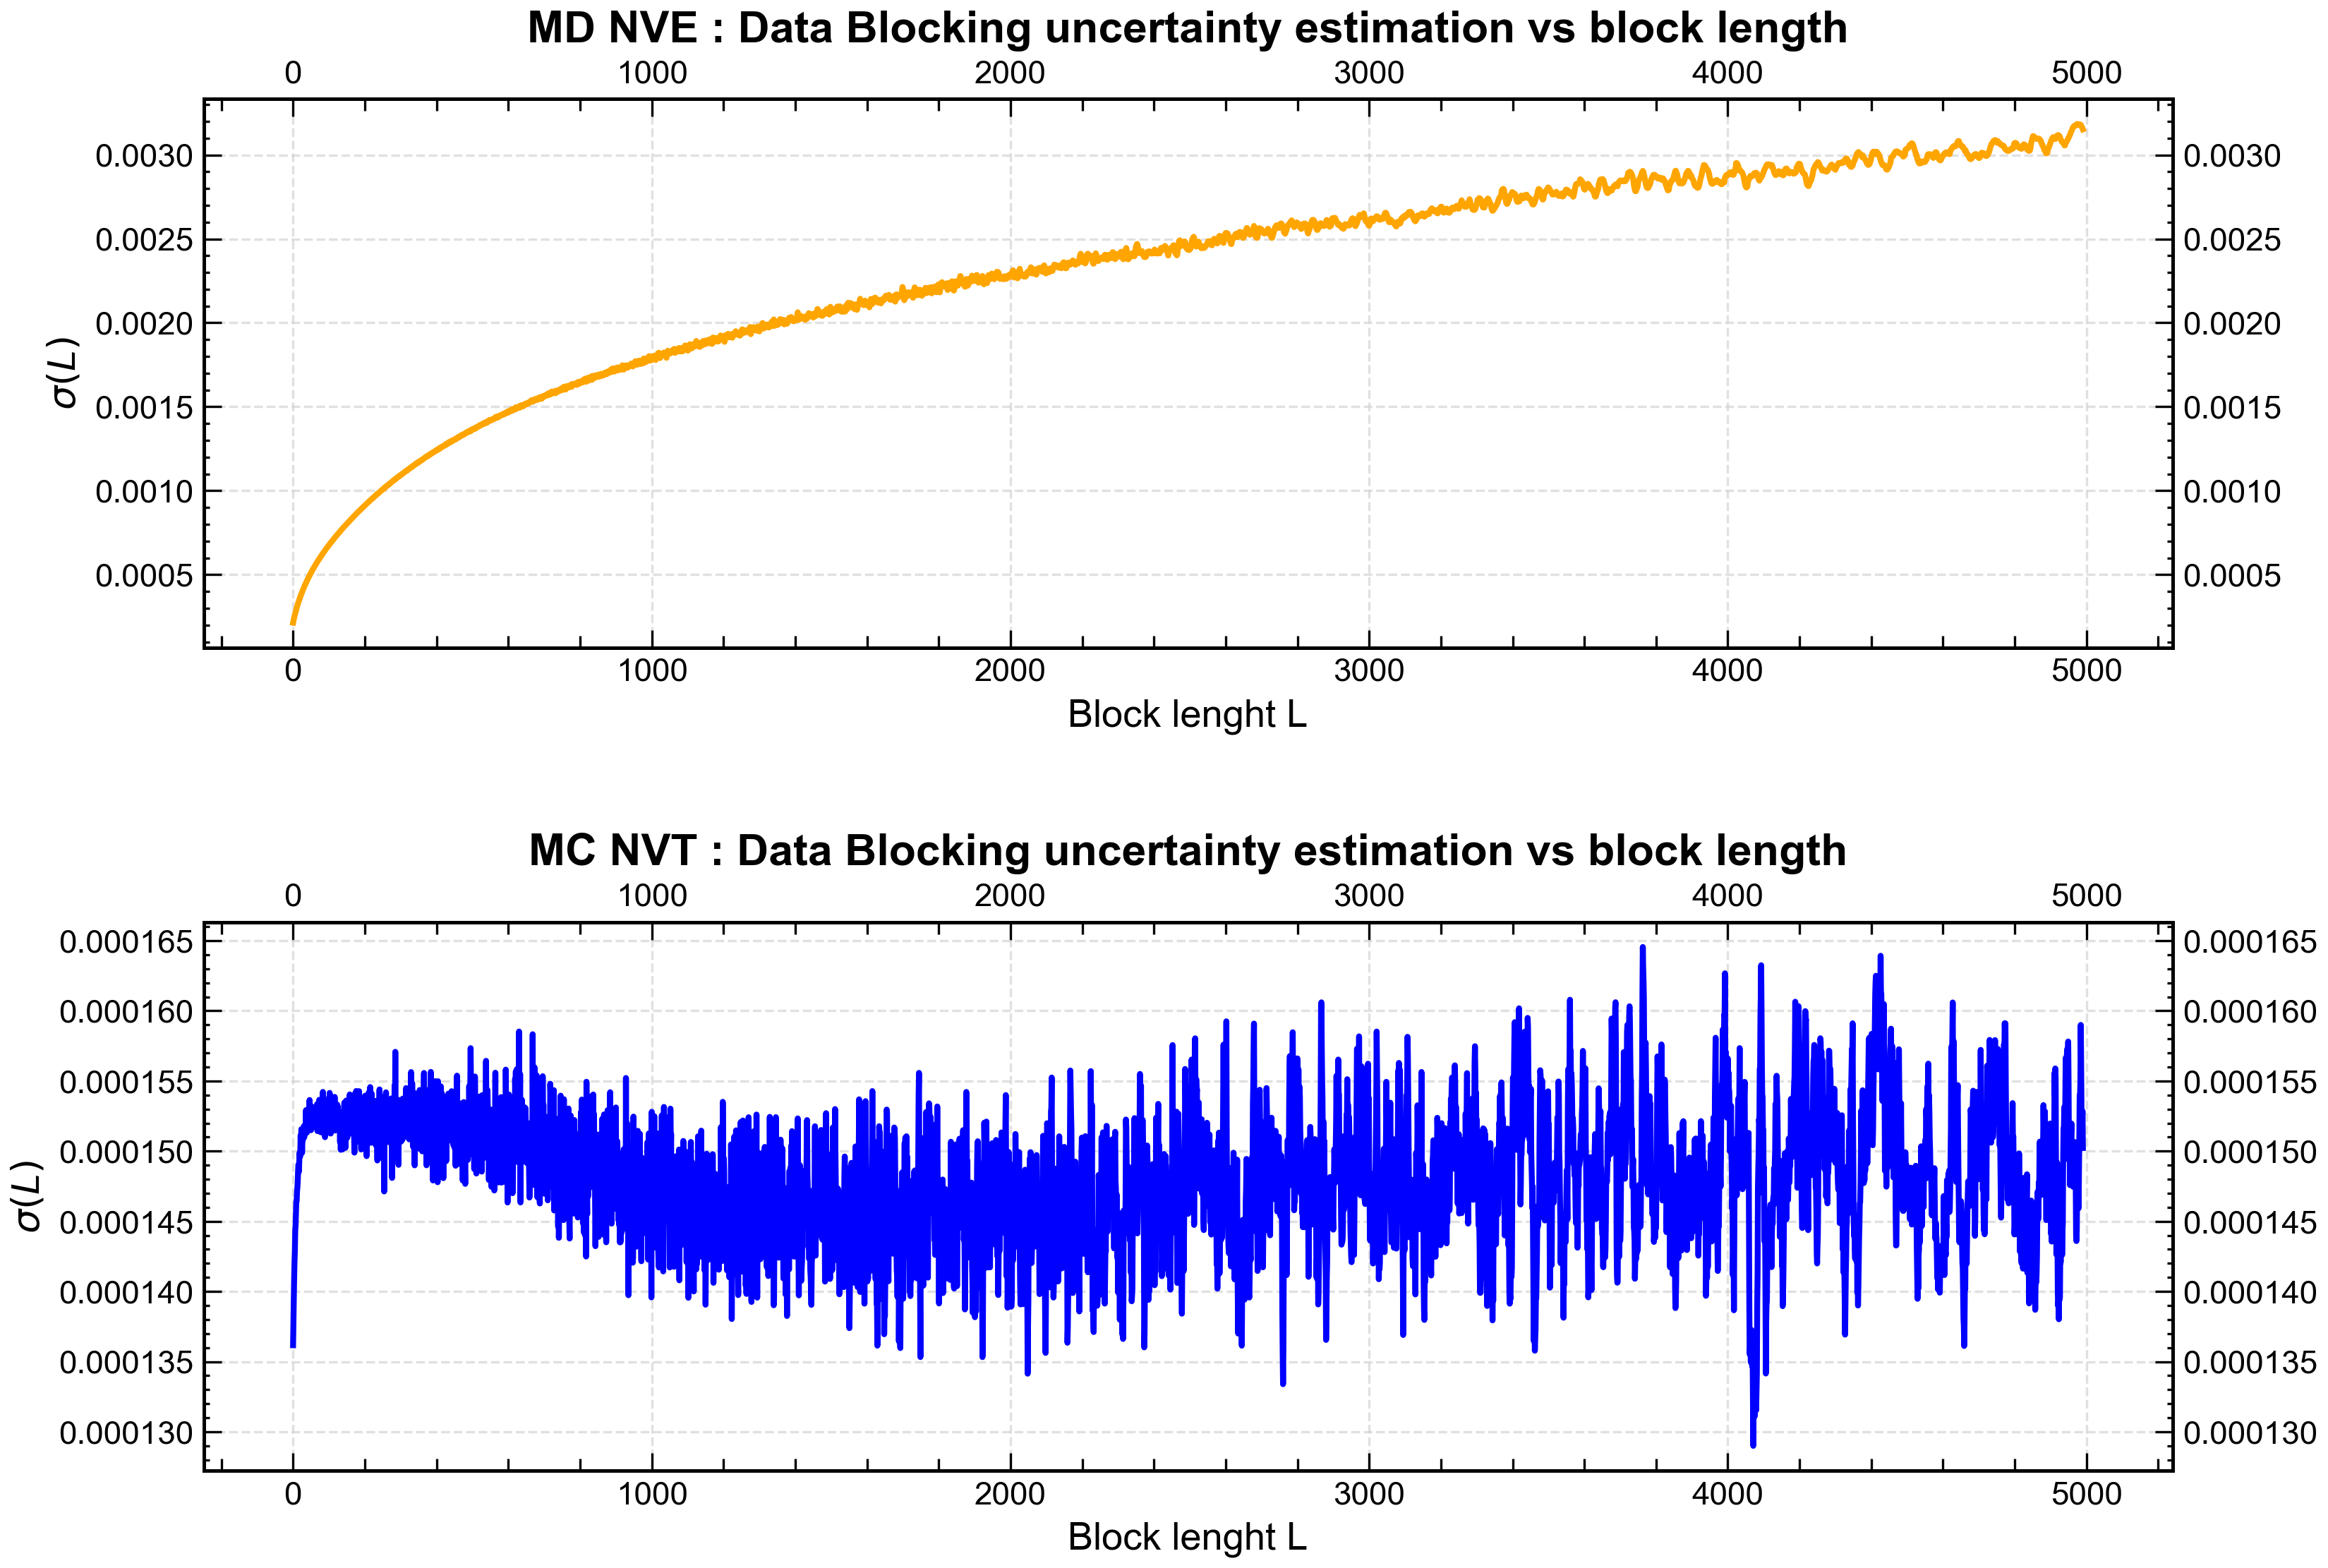

In [75]:
x = np.arange(0, len(err_NVE))

fig, axs = plt.subplots(2, 1, figsize=(12,8))

axs[0].set_title("MD NVE : Data Blocking uncertainty estimation vs block length")
axs[0].plot(x, err_NVE, color="orange")
axs[0].set_xlabel("Block lenght L")
axs[0].set_ylabel(r"$\sigma (L)$")

axs[1].set_title("MC NVT : Data Blocking uncertainty estimation vs block length")
axs[1].plot(x, err_NVT, color="blue")
axs[1].set_xlabel("Block lenght L")
axs[1].set_ylabel(r"$\sigma (L)$")

fig.subplots_adjust(
        wspace=0.3,  # Spazio orizzontale
        hspace=0.5, # Spazio verticale
        top=0.92     # move below plots (gives space to suptitle)
)
fig.savefig("plot/gas/autocorrelation/data_block_error.png")

plt.show()

In [76]:
blocks, pot_en_NVE, pot_en_err_NVE = np.loadtxt("MD_NVE/gas/run/OUTPUT/potential_energy.dat", usecols=(0,2,3), unpack=True)
press_NVE, press_err_NVE = np.loadtxt("MD_NVE/gas/run/OUTPUT/pressure.dat", usecols=(2,3), unpack=True)
bin_center, gofr_NVE, gofr_err_NVE = np.loadtxt("MD_NVE/gas/run/OUTPUT/gofr.dat", usecols=(1,3,4), unpack=True)
pot_en_NVT, pot_en_err_NVT = np.loadtxt("MC_NVT/gas/run/OUTPUT/potential_energy.dat", usecols=(2,3), unpack=True)
press_NVT, press_err_NVT = np.loadtxt("MC_NVT/gas/run/OUTPUT/pressure.dat", usecols=(2,3), unpack=True)
gofr_NVT, gofr_err_NVT = np.loadtxt("MC_NVT/gas/run/OUTPUT/gofr.dat", usecols=(3,4), unpack=True)

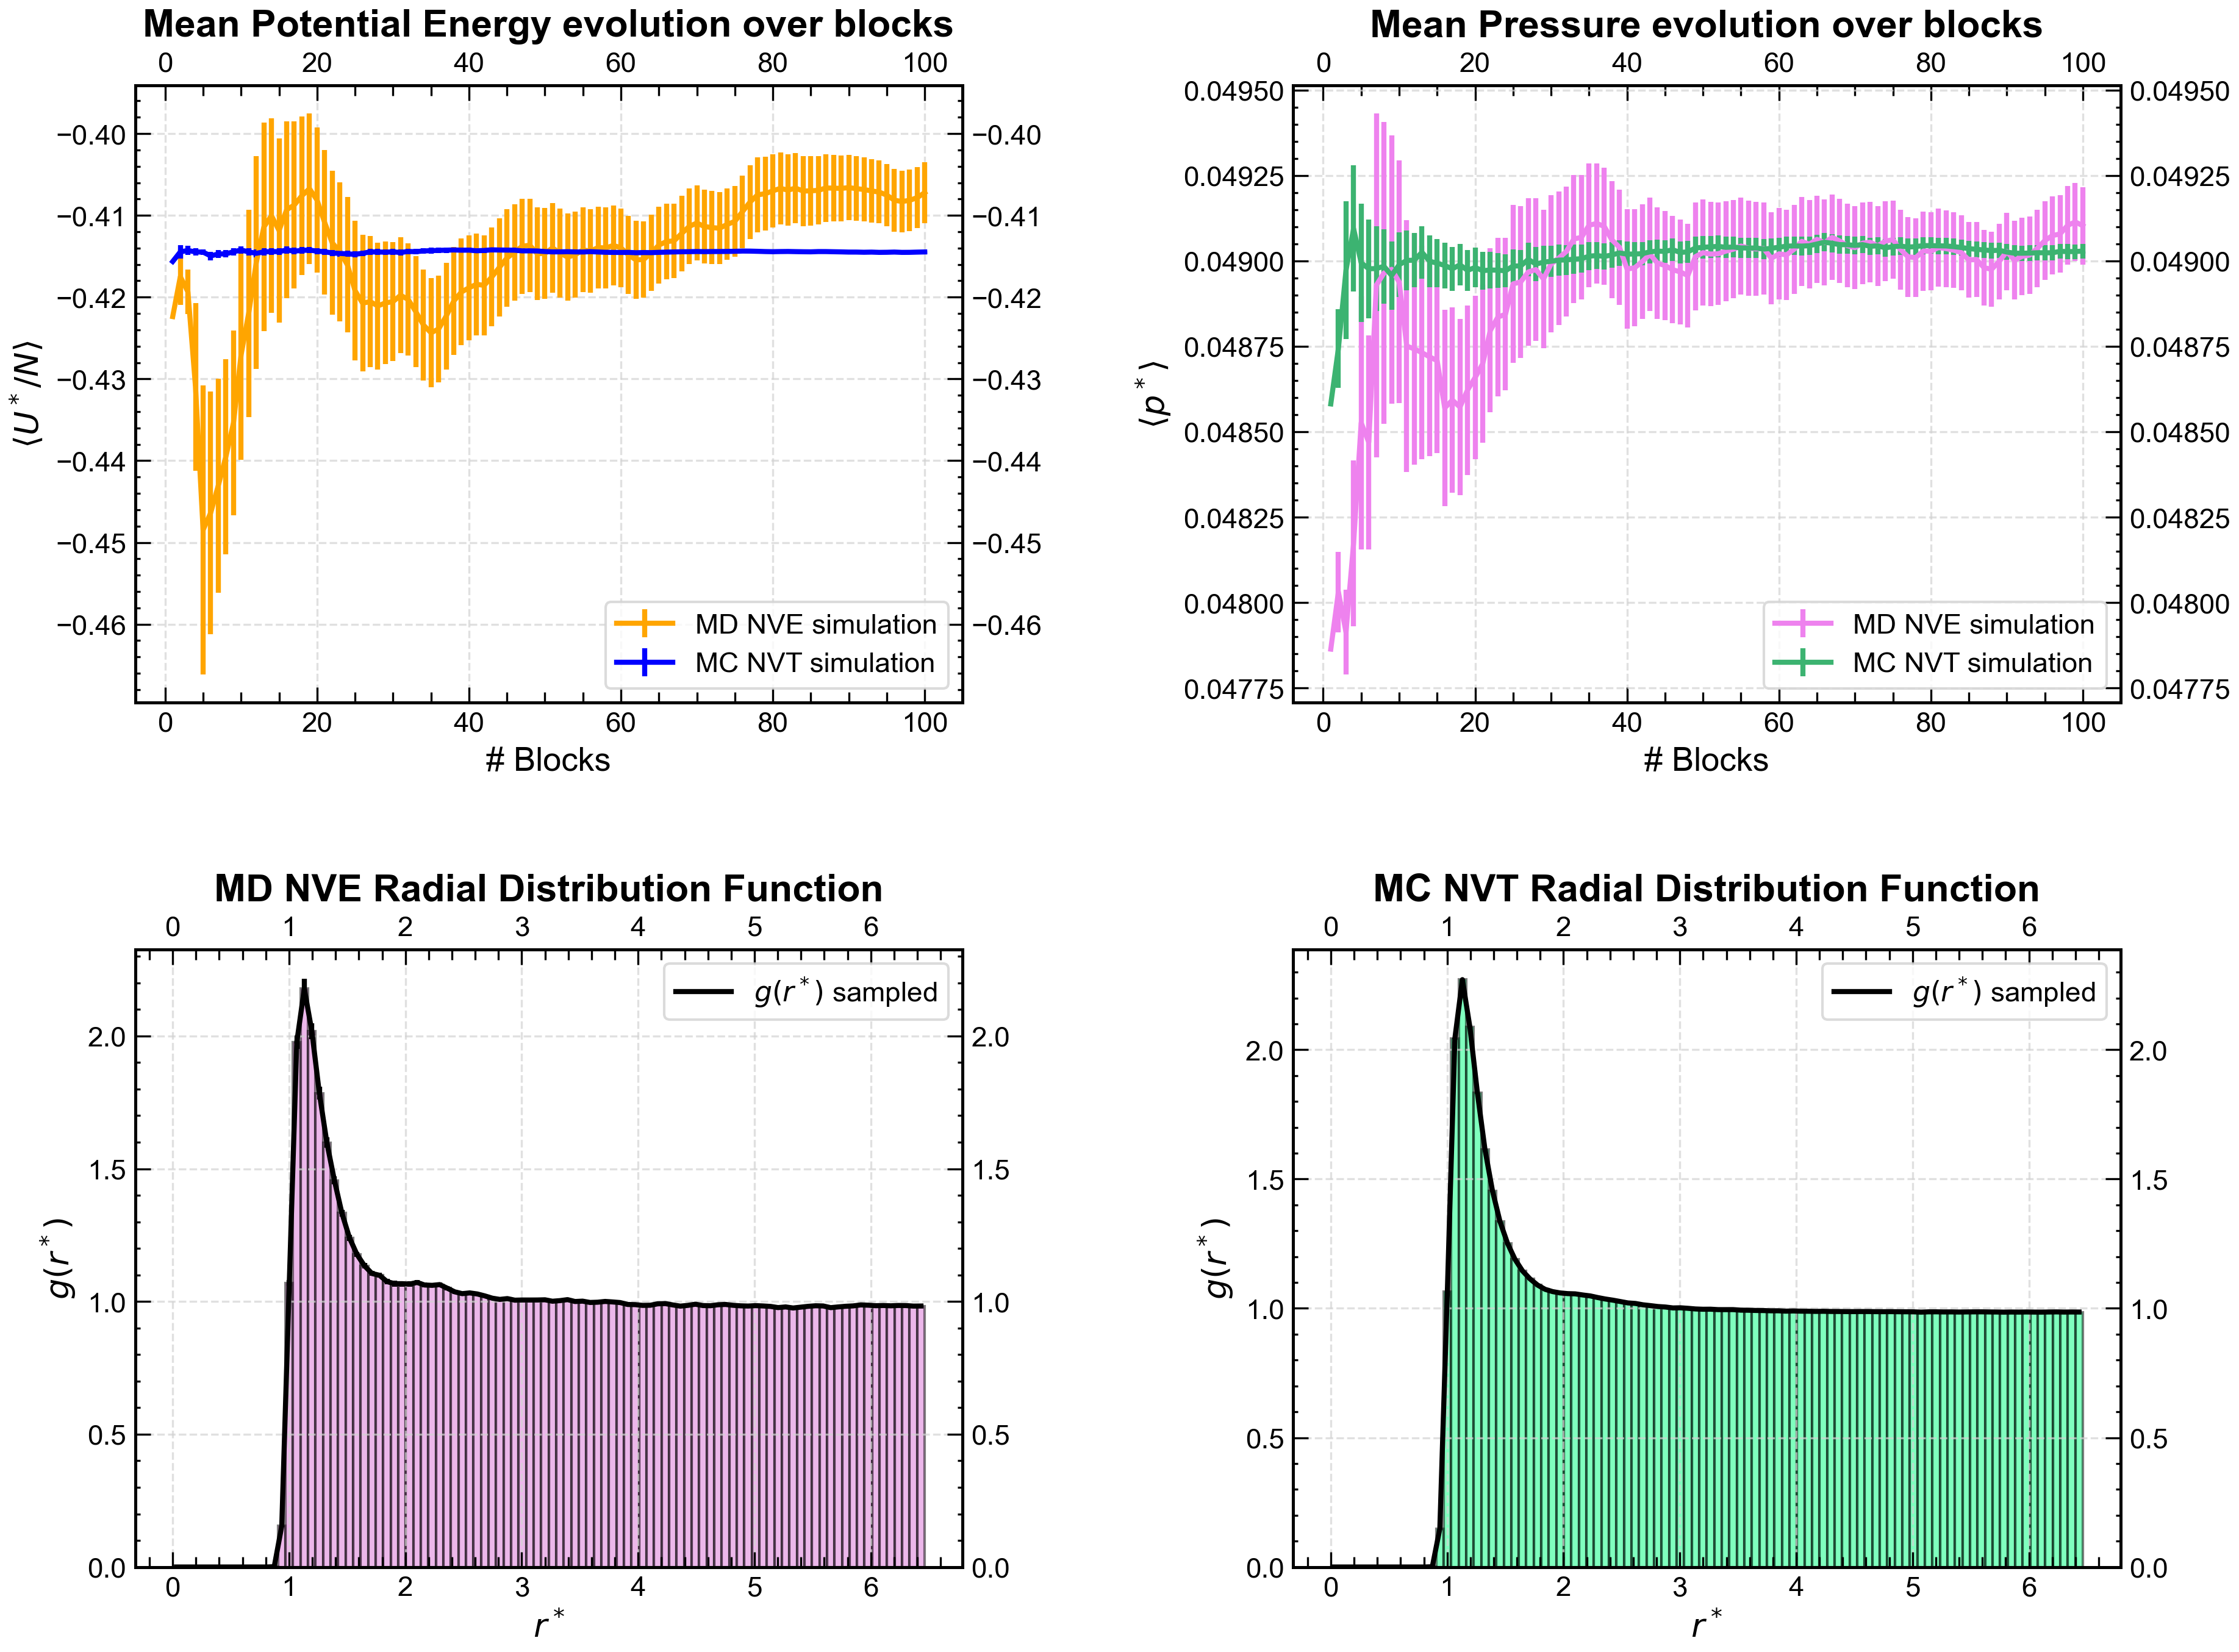

In [77]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0][0].set_title("Mean Potential Energy evolution over blocks")
axs[0][0].set_xlabel("# Blocks")
axs[0][0].set_ylabel(r"$\langle U^*/N \rangle$")
axs[0][0].errorbar(blocks, pot_en_NVE, yerr=pot_en_err_NVE, color = "orange", label="MD NVE simulation")
axs[0][0].errorbar(blocks, pot_en_NVT, yerr=pot_en_err_NVT, color = "blue", label="MC NVT simulation")
axs[0][0].legend(loc="lower right")

axs[0][1].set_title("Mean Pressure evolution over blocks")
axs[0][1].set_xlabel("# Blocks")
axs[0][1].set_ylabel(r"$\langle p^* \rangle$")
axs[0][1].errorbar(blocks, press_NVE, yerr=press_err_NVE, color = "violet", label="MD NVE simulation")
axs[0][1].errorbar(blocks, press_NVT, yerr=press_err_NVT, color = "mediumseagreen", label="MC NVT simulation")
axs[0][1].legend(loc="lower right")

axs[1][0].set_title("MD NVE Radial Distribution Function")
axs[1][0].set_xlabel(r"$r^*$")
axs[1][0].set_ylabel(r"$g(r^*)$")
axs[1][0].bar(bin_center, gofr_NVE, width=2*bin_center[0], alpha=0.5, color="orchid", edgecolor="black", yerr=gofr_err_NVE, ecolor="black")
axs[1][0].plot(bin_center, gofr_NVE, color="black", label=r"$g(r^*)$ sampled")
axs[1][0].legend()

axs[1][1].set_title("MC NVT Radial Distribution Function")
axs[1][1].set_xlabel(r"$r^*$")
axs[1][1].set_ylabel(r"$g(r^*)$")
axs[1][1].bar(bin_center, gofr_NVT, width=2*bin_center[0], alpha=0.5, color="springgreen", edgecolor="black", yerr=gofr_err_NVT, ecolor="black")
axs[1][1].plot(bin_center, gofr_NVT, color="black", label=r"$g(r^*)$ sampled")
axs[1][1].legend()

fig.subplots_adjust(
        wspace=0.4,  # Spazio orizzontale
        hspace=0.4, # Spazio verticale
        top=0.92     # move below plots (gives space to suptitle)
)

fig.savefig("plot/gas/run/pe_pre_gofr.png")
plt.show()


<h4>Conclusions</h4>

Even in the case of the gas phase, the sampled RDF $g(r)$ obtained by simulating a microcanonical ensemble via MD simulations or a canonical ensemble via MCMC simulations is nearly identical. This observation verifies the hypothesis of ensemble equivalence for this structural property in large systems.

However, the structural behavior fundamentally differs from that of the liquid phase. For real gases modeled by the Lennard-Jones (LJ) potential, the function $g(r)$ approaches zero for $r < \sigma$ due to the strong short-range repulsion, which effectively prohibits particles from occupying the same space. The function exhibits its first and typically only significant peak at a distance close to the potential minimum. Beyond this short-range interaction region, the $g(r)$ decays very rapidly to unity. This rapid convergence signifies that inter-particle correlations are strictly local. The physical implication is that at distances greater than a few multiples of $\sigma$, the gas behaves similarly to an ideal gas because the LJ interactions are negligible due to the low density and the short-range nature of the potential.